# Model - Binary Classification | Logistic & XG-Boost
Created by Guillermo Arredondo Renero

Creation date: May 5, 2026  
Last updated: May 5, 2026

**Main objective**: Find and train best Logistic model. It is meant to be a baseline model. Then find and train best XG Boost model.

In [37]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable

# Extras
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
     accuracy_score, recall_score, f1_score, precision_score)
from scipy.stats import ks_2samp
import optuna
from optuna.visualization import plot_optimization_history

import joblib
import pickle
import shap

RANDOM_STATE = 56

In [38]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
PROCESSED_DIR = os.path.join(MAIN_DIR, 'data', 'processed', 'binary_classification')
MODELS_DIR = os.path.join(MAIN_DIR, 'outputs', 'models', 'binary_classification')
os.makedirs(MODELS_DIR, exist_ok=True)

## Data loading

In [39]:
train = pd.read_csv(os.path.join(PROCESSED_DIR, 'train', 'train_data.csv'))
train_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'train', 'train_data_scaled.csv'))

test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test', 'test_data.csv'))
test_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'test', 'test_data_scaled.csv'))

val = pd.read_csv(os.path.join(PROCESSED_DIR, 'val', 'val_data.csv'))
val_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'val', 'val_data_scaled.csv'))

In [40]:
# Quick sanity checks
print(f"Train set shape: {train.shape} - scaled equals: {train_scaled.shape == train.shape}")
print(f"Validation set shape: {val.shape} - scaled equals: {val_scaled.shape == val.shape}")
print(f"Test set shape: {test.shape} - scaled equals: {test_scaled.shape == test.shape}")

assert not train.isnull().any().any(), "Train set contains null values"
assert not val.isnull().any().any(), "Validation set contains null values"
assert not test.isnull().any().any(), "Test set contains null values"

assert not train_scaled.isnull().any().any(), "Train scaled set contains null values"
assert not val_scaled.isnull().any().any(), "Validation scaled set contains null values"
assert not test_scaled.isnull().any().any(), "Test scaled set contains null values"

print("Original info:")
print(train.info())
print(test.info())
print(val.info())
print("="*80)
print("Scaled info:")
print(train_scaled.info())
print(test_scaled.info())
print(val_scaled.info())

Train set shape: (19240, 64) - scaled equals: True
Validation set shape: (4440, 64) - scaled equals: True
Test set shape: (5921, 64) - scaled equals: True
Original info:
<class 'pandas.DataFrame'>
RangeIndex: 19240 entries, 0 to 19239
Data columns (total 64 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   19240 non-null  int64  
 1   SEX                         19240 non-null  int64  
 2   AGE                         19240 non-null  int64  
 3   PAY_1                       19240 non-null  int64  
 4   PAY_2                       19240 non-null  int64  
 5   PAY_3                       19240 non-null  int64  
 6   PAY_4                       19240 non-null  int64  
 7   PAY_5                       19240 non-null  int64  
 8   PAY_6                       19240 non-null  int64  
 9   BILL_AMT1                   19240 non-null  int64  
 10  BILL_AMT2                   19240 non-null 

In [41]:
x_train = train.drop('default_payment_next_month', axis = 1)
y_train = train['default_payment_next_month']

x_train_scaled = train_scaled.drop('default_payment_next_month', axis = 1)
y_train_scaled = train_scaled['default_payment_next_month']
#-----------
x_test = test.drop('default_payment_next_month', axis = 1)
y_test = test['default_payment_next_month']

x_test_scaled = test_scaled.drop('default_payment_next_month', axis = 1)
y_test_scaled = test_scaled['default_payment_next_month']
#-----------
x_val = val.drop('default_payment_next_month', axis = 1)
y_val = val['default_payment_next_month']

x_val_scaled = val_scaled.drop('default_payment_next_month', axis = 1)
y_val_scaled = val_scaled['default_payment_next_month']

## Feature Selection

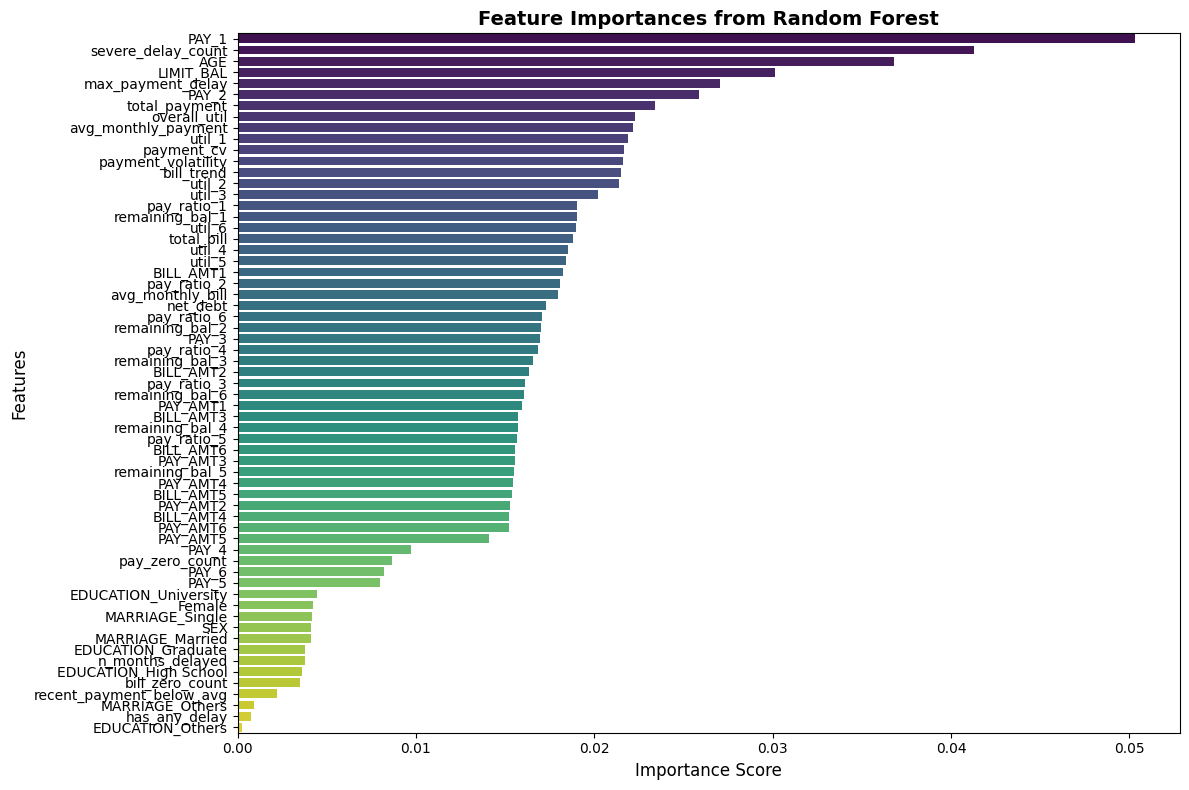

In [42]:
# Train RandomForest for feature importance analysis
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(x_train, y_train)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances, x='importance', y='feature', palette='viridis')
plt.title('Feature Importances from Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '' 'feature_importances.png'), dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# Define selected features (top features with importance > threshold or top N features)
# Using top 20 features as baseline
n_features = 20
selected_features = feature_importances.head(n_features)['feature'].tolist()

dummy_groups = [
    ['MARRIAGE_Married', 'MARRIAGE_Others', 'MARRIAGE_Single'],
    ['EDUCATION_Graduate', 'EDUCATION_High School', 'EDUCATION_Others', 'EDUCATION_University']
]

selected_features_set = set(selected_features)
for group in dummy_groups:
    if any(feature in selected_features_set for feature in group):
        selected_features_set.update(group)

selected_features = [feature for feature in x_train.columns if feature in selected_features_set]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

# Apply feature selection to all datasets
x_train_selected = x_train[selected_features]
x_train_scaled_selected = x_train_scaled[selected_features]

x_val_selected = x_val[selected_features]
x_val_scaled_selected = x_val_scaled[selected_features]

x_test_selected = x_test[selected_features]
x_test_scaled_selected = x_test_scaled[selected_features]

print(f"\nOriginal training set shape: {x_train.shape}")
print(f"Selected training set shape: {x_train_selected.shape}")
print(f"Original validation set shape: {x_val.shape}")
print(f"Selected validation set shape: {x_val_selected.shape}")
print(f"Original test set shape: {x_test.shape}")
print(f"Selected test set shape: {x_test_selected.shape}")

Selected 20 features:
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'util_1', 'util_2', 'util_3', 'util_4', 'util_6', 'pay_ratio_1', 'remaining_bal_1', 'avg_monthly_payment', 'max_payment_delay', 'severe_delay_count', 'bill_trend', 'payment_volatility', 'payment_cv', 'total_bill', 'total_payment', 'overall_util']

Original training set shape: (19240, 63)
Selected training set shape: (19240, 20)
Original validation set shape: (4440, 63)
Selected validation set shape: (4440, 20)
Original test set shape: (5921, 63)
Selected test set shape: (5921, 20)


## Model Training and Hyperparameter Tuning

### Logistic Regression

In [44]:
# Get best Logistic Regression model from Optuna study
# Define Optuna objective function
def tune_lr_classifier(X_train, y_train, X_val, y_val, n_trials, metric):
    
    def optuna_objective(trial):
        """
        Objective function for Optuna optimization.
        Optimizes the specified metric.
        """
        # Hyperparameters to tune
        solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])

        if solver == 'lbfgs':
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 0.0)
        else:
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
         
        params = {
            'C': trial.suggest_float('C', 1e-4, 1e2, log=True),  # Inverse regularization strength
            'max_iter': trial.suggest_int('max_iter', 500, 2000, step=100),  # Max iterations
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),  # Handle imbalance
        }
        
        # Create model
        model = LogisticRegression(
            C=params['C'],
            solver=solver,
            l1_ratio=l1_ratio,
            max_iter=params['max_iter'],
            class_weight=params['class_weight'],
            random_state=RANDOM_STATE
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Compute all metrics
        metrics = {
            'auc_roc':  roc_auc_score(y_val, y_pred_proba),
            'accuracy': accuracy_score(y_val, y_pred),
            'f1':       f1_score(y_val, y_pred),
            'recall':   recall_score(y_val, y_pred),
            'precision':precision_score(y_val, y_pred)
        }
        
        # Log all metrics but return only the specified one for optimization
        for metric_name, metric_value in metrics.items():
            trial.set_user_attr(metric_name, metric_value)
        
        return metrics[metric]

    # Create Optuna study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )

    # Optimize
    print("\nRunning Optuna optimization (this may take a few minutes)...")
    study.optimize(optuna_objective, n_trials=n_trials, n_jobs=-1, show_progress_bar=True)

    return study, study.best_params, study.best_value

In [45]:
lr_study, lr_best_params, lr_best_score = tune_lr_classifier(
    x_train_scaled_selected, y_train_scaled, x_val_scaled_selected, y_val_scaled, n_trials=35, metric='auc_roc'
)

# Visualize optimization history
fig = plot_optimization_history(lr_study).show()
print(f"\n✅ Optimization Complete!")
print(f"Best AUC-ROC : {lr_best_score:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in lr_best_params.items():
    print(f"  • {param}: {value}")

# Save Optuna results
optuna_results_lr = {
    'lr_best_params': lr_best_params,
    'lr_best_score': lr_best_score,
    'n_trials': len(lr_study.trials),
    'trials_df': lr_study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
}

optuna_results_lr['trials_df'].to_csv(os.path.join(MODELS_DIR, 'lr_optuna_trials.csv'), index=False)
optuna_results_lr['trials_df'].sort_values('value', ascending=False).head(10)

[I 2026-05-06 03:05:19,003] A new study created in memory with name: no-name-c8dede1c-a536-46bb-bb46-3a15eb523a80



Running Optuna optimization (this may take a few minutes)...


Best trial: 6. Best value: 0.746726:   3%|▎         | 1/35 [00:01<00:57,  1.71s/it]

[I 2026-05-06 03:05:20,679] Trial 6 finished with value: 0.7467257506599698 and parameters: {'solver': 'lbfgs', 'l1_ratio': 0.0, 'C': 0.007301372074892202, 'max_iter': 1600, 'class_weight': None}. Best is trial 6 with value: 0.7467257506599698.


Best trial: 0. Best value: 0.746955:   6%|▌         | 2/35 [00:03<01:02,  1.89s/it]

...

[I 2026-05-06 03:06:49,034] Trial 16 finished with value: 0.7323584045332316 and parameters: {'solver': 'saga', 'l1_ratio': 0.3745757517627396, 'C': 3.370231562137928, 'max_iter': 1000, 'class_weight': 'balanced'}. Best is trial 19 with value: 0.7504537064370872.


Best trial: 19. Best value: 0.750454: 100%|██████████| 35/35 [01:32<00:00,  2.64s/it]

[I 2026-05-06 03:06:51,306] Trial 2 finished with value: 0.5842711981038977 and parameters: {'solver': 'saga', 'l1_ratio': 0.6934574199695557, 'C': 0.012732271668652661, 'max_iter': 1800, 'class_weight': None}. Best is trial 19 with value: 0.7504537064370872.



✅ Optimization Complete!
Best AUC-ROC : 0.7505

Best Hyperparameters:
  • solver: lbfgs
  • l1_ratio: 0.0
  • C: 0.007599538916529132
  • max_iter: 1600
  • class_weight: balanced


,number,value,params_C,params_class_weight,params_l1_ratio,params_max_iter,params_solver,user_attrs_accuracy,user_attrs_auc_roc,user_attrs_f1,user_attrs_precision,user_attrs_recall
19,19,0.750454,0.007600,balanced,0.0,1600,lbfgs,0.745946,0.750454,0.517536,0.449146,0.610494
15,15,0.750435,0.007283,balanced,0.0,1700,lbfgs,0.745495,0.750435,0.516681,0.448404,0.609485
18,18,0.750312,54.787136,balanced,0.0,2000,lbfgs,0.742117,0.750312,0.512143,0.443215,0.606458
34,34,0.750307,17.433400,balanced,0.0,1600,lbfgs,0.742117,0.750307,0.511727,0.443131,0.605449
22,22,0.750291,0.033084,balanced,0.0,1700,lbfgs,0.746396,0.750291,0.517979,0.449814,0.610494
3,3,0.750285,49.620636,balanced,0.0,1500,lbfgs,0.742117,0.750285,0.511727,0.443131,0.605449
25,25,0.750273,0.054115,balanced,0.0,900,lbfgs,0.745721,0.750273,0.517315,0.448813,0.610494
33,33,0.750269,16.434734,balanced,0.0,1600,lbfgs,0.742117,0.750269,0.512143,0.443215,0.606458
24,24,0.750266,0.068636,balanced,0.0,900,lbfgs,0.745946,0.750266,0.517536,0.449146,0.610494
23,23,0.750249,0.055321,balanced,0.0,900,lbfgs,0.746171,0.750249,0.517758,0.449480,0.610494


In [46]:
joblib.dump(optuna_results_lr, os.path.join(MODELS_DIR, 'lr_optuna_results.pkl'))

['c:\\Users\\Memit\\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\\Documentos\\AplicacionesTrabajo\\Bluetab\\default_credit_prediction\\outputs\\models\\binary_classification\\lr_optuna_results.pkl']

### XGBoost

In [47]:
# Get best XGBoost model from Optuna study
# Define Optuna objective function
def tune_xgb_classifier(X_train, y_train, X_val, y_val, n_trials, metric):

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    def optuna_objective(trial):
        """
        Objective function for Optuna optimization.
        Optimizes the specific metric.
        """

        handle_imbalance = trial.suggest_categorical('handle_imbalance', [True, False])

        params = {
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': scale_pos_weight if handle_imbalance else 1.0,
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }
        model = xgb.XGBClassifier(**params)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Compute all metrics
        metrics = {
            'auc_roc':  roc_auc_score(y_val, y_pred_proba),
            'accuracy': accuracy_score(y_val, y_pred),
            'f1':       f1_score(y_val, y_pred),
            'recall':   recall_score(y_val, y_pred),
            'precision':precision_score(y_val, y_pred)
        }
        
        # Log all metrics but return only the specified one for optimization
        for metric_name, metric_value in metrics.items():
            trial.set_user_attr(metric_name, metric_value)
        
        return metrics[metric]

    # Create Optuna study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )

    # Optimize
    print("\nRunning Optuna optimization (this may take a few minutes)...")
    study.optimize(optuna_objective, n_trials=n_trials, n_jobs=-1, show_progress_bar=True)

    return study, study.best_params, study.best_value

In [48]:
xgb_study, xgb_best_params, xgb_best_score = tune_xgb_classifier(
    x_train_selected, y_train, x_val_selected, y_val, n_trials=35, metric='auc_roc'
)

print(f"\n✅ Optimization Complete!")
print(f"Best AUC-ROC : {xgb_best_score:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in xgb_best_params.items():
    print(f"  • {param}: {value}")

# Visualize optimization history
fig = plot_optimization_history(xgb_study).show()

# Save Optuna results
optuna_results_xgb = {
    'xgb_best_params': xgb_best_params,
    'xgb_best_score': xgb_best_score,
    'n_trials': len(xgb_study.trials),
    'trials_df': xgb_study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
}

optuna_results_xgb['trials_df'].to_csv(os.path.join(MODELS_DIR, 'xgb_optuna_trials.csv'), index=False)
optuna_results_xgb['trials_df'].sort_values('value', ascending=False).head(10)

[I 2026-05-06 03:06:51,600] A new study created in memory with name: no-name-541d48f4-589e-4824-bead-13348ddc3ee7



Running Optuna optimization (this may take a few minutes)...


  0%|          | 0/35 [00:00<?, ?it/s]

Best trial: 3. Best value: 0.7825:   3%|▎         | 1/35 [00:04<02:19,  4.09s/it]

[I 2026-05-06 03:06:55,681] Trial 3 finished with value: 0.7825000241372118 and parameters: {'handle_imbalance': True, 'max_depth': 3, 'learning_rate': 0.019858126916951747, 'n_estimators': 164, 'subsample': 0.7939078746592096, 'colsample_bytree': 0.7275639305542704}. Best is trial 3 with value: 0.7825000241372118.


...

Best trial: 31. Best value: 0.783139:  97%|█████████▋| 34/35 [00:38<00:00,  2.44it/s]

[I 2026-05-06 03:07:30,267] Trial 34 finished with value: 0.7821679546185312 and parameters: {'handle_imbalance': True, 'max_depth': 4, 'learning_rate': 0.015016967169632182, 'n_estimators': 223, 'subsample': 0.7493409010357347, 'colsample_bytree': 0.9373865643119129}. Best is trial 31 with value: 0.7831392945322048.


Best trial: 31. Best value: 0.783139: 100%|██████████| 35/35 [00:38<00:00,  1.11s/it]

[I 2026-05-06 03:07:30,554] Trial 33 finished with value: 0.7820300067964536 and parameters: {'handle_imbalance': True, 'max_depth': 4, 'learning_rate': 0.0130194113037721, 'n_estimators': 296, 'subsample': 0.754040017959555, 'colsample_bytree': 0.675166596054479}. Best is trial 31 with value: 0.7831392945322048.

✅ Optimization Complete!
Best AUC-ROC : 0.7831

Best Hyperparameters:
  • handle_imbalance: True
  • max_depth: 4
  • learning_rate: 0.01897175061368188
  • n_estimators: 157
  • subsample: 0.610388058281971
  • colsample_bytree: 0.729246811042681


,number,value,params_colsample_bytree,params_handle_imbalance,params_learning_rate,params_max_depth,params_n_estimators,params_subsample,user_attrs_accuracy,user_attrs_auc_roc,user_attrs_f1,user_attrs_precision,user_attrs_recall
31,31,0.783139,0.729247,True,0.018972,4,157,0.610388,0.755405,0.783139,0.532300,0.464313,0.623613
12,12,0.782874,0.948627,False,0.011749,3,286,0.642511,0.820045,0.782874,0.468397,0.687500,0.355197
18,18,0.782689,0.767687,True,0.070202,3,109,0.832478,0.749099,0.782689,0.529163,0.455273,0.631685
30,30,0.782647,0.727406,True,0.017569,3,302,0.816757,0.751351,0.782647,0.532203,0.458729,0.633703
25,25,0.782571,0.836128,True,0.004061,5,303,0.619001,0.756982,0.782571,0.533506,0.466717,0.622603
3,3,0.782500,0.727564,True,0.019858,3,164,0.793908,0.750450,0.782500,0.529711,0.457143,0.629667
28,28,0.782412,0.724096,True,0.021702,3,149,0.600520,0.751351,0.782412,0.529813,0.458364,0.627649
8,8,0.782351,0.975567,False,0.008110,4,341,0.728746,0.820721,0.782351,0.467914,0.693069,0.353179
20,20,0.782345,0.769297,True,0.063435,3,103,0.845975,0.750225,0.782345,0.529886,0.456871,0.630676
34,34,0.782168,0.937387,True,0.015017,4,223,0.749341,0.755856,0.782168,0.531547,0.464853,0.620585


In [49]:
joblib.dump(optuna_results_xgb, os.path.join(MODELS_DIR, 'xgb_optuna_results.pkl'))

['c:\\Users\\Memit\\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\\Documentos\\AplicacionesTrabajo\\Bluetab\\default_credit_prediction\\outputs\\models\\binary_classification\\xgb_optuna_results.pkl']

## Predict & Evaluation

FINAL MODEL TRAINING & EVALUATION | Logistic Regression

Training final model with best hyperparameters...

### Validation Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7505
Accuracy       : 0.7459
Precision      : 0.4491
Recall         : 0.6105
F1-Score       : 0.5175

Confusion Matrix (Validation):
[[2707  742]
 [ 386  605]]

Classification Report (Validation):
              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83      3449
     Default       0.45      0.61      0.52       991

    accuracy                           0.75      4440
   macro avg       0.66      0.70      0.67      4440
weighted avg       0.78      0.75      0.76      4440


### Test Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7438
Accuracy       : 0.7443
Precision      : 0.4469
Recall         : 0.6147
F1-Score       : 0.5175

Confusion

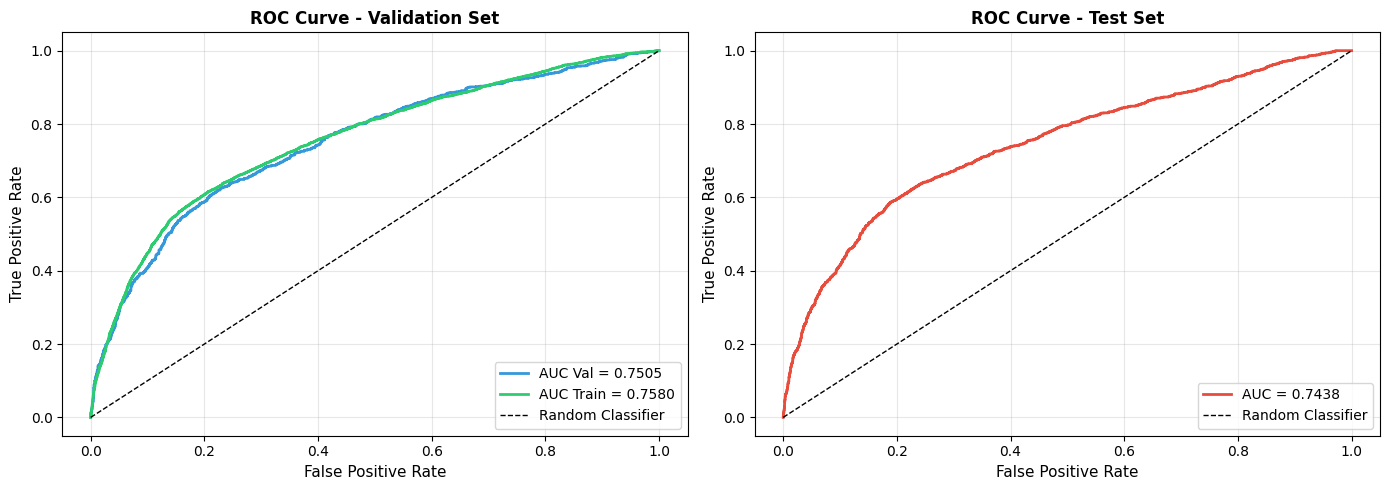

In [50]:
print("FINAL MODEL TRAINING & EVALUATION | Logistic Regression")
print("="*80)

# Use best model
print("\nTraining final model with best hyperparameters...")
best_lr_model = LogisticRegression(
    C=lr_best_params['C'],
    solver=lr_best_params['solver'],
    l1_ratio = lr_best_params['l1_ratio'],
    max_iter=lr_best_params['max_iter'],
    class_weight=lr_best_params['class_weight'],
    random_state=RANDOM_STATE
)

# Train on full training set
best_lr_model.fit(x_train_scaled_selected, y_train_scaled)

# ========== VALIDATION SET EVALUATION ==========
print("\n### Validation Set Performance")
print("-" * 80)

y_tr_pred = best_lr_model.predict(x_train_scaled_selected)
y_tr_pred_proba = best_lr_model.predict_proba(x_train_scaled_selected)[:, 1]

y_val_pred = best_lr_model.predict(x_val_scaled_selected)
y_val_pred_proba = best_lr_model.predict_proba(x_val_scaled_selected)[:, 1]

val_metrics = {
    'AUC-ROC': roc_auc_score(y_val_scaled, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val_scaled, y_val_pred),
    'Precision': precision_score(y_val_scaled, y_val_pred),
    'Recall': recall_score(y_val_scaled, y_val_pred),
    'F1-Score': f1_score(y_val_scaled, y_val_pred)
}

for metric, value in val_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val_scaled, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_scaled, y_val_pred, target_names=['No Default', 'Default']))

# ========== TEST SET EVALUATION ==========
print("\n### Test Set Performance")
print("-" * 80)

y_test_pred = best_lr_model.predict(x_test_scaled_selected)
y_test_pred_proba = best_lr_model.predict_proba(x_test_scaled_selected)[:, 1]

test_metrics = {
    'AUC-ROC': roc_auc_score(y_test_scaled, y_test_pred_proba),
    'Accuracy': accuracy_score(y_test_scaled, y_test_pred),
    'Precision': precision_score(y_test_scaled, y_test_pred),
    'Recall': recall_score(y_test_scaled, y_test_pred),
    'F1-Score': f1_score(y_test_scaled, y_test_pred)
}

for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_scaled, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test_scaled, y_test_pred, target_names=['No Default', 'Default']))

# ========== ROC CURVE VISUALIZATION ==========
print("\n### ROC Curve Comparison")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation ROC
fpr_val, tpr_val, _ = roc_curve(y_val_scaled, y_val_pred_proba)
auc_val = roc_auc_score(y_val_scaled, y_val_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC Val = {auc_val:.4f}', color='#3498db')
fpr_tr, tpr_tr, _ = roc_curve(y_train_scaled, y_tr_pred_proba)
auc_tr = roc_auc_score(y_train_scaled, y_tr_pred_proba)
axes[0].plot(fpr_tr, tpr_tr, lw=2, label=f'AUC Train = {auc_tr:.4f}', color='#2ecc71')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve - Validation Set', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test_scaled, y_test_pred_proba)
auc_test = roc_auc_score(y_test_scaled, y_test_pred_proba)
axes[1].plot(fpr_test, tpr_test, lw=2, label=f'AUC = {auc_test:.4f}', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance (Logistic Coefficients)
--------------------------------------------------------------------------------

Top 15 Most Important Features:
            feature  coefficient  abs_coefficient
 severe_delay_count     0.490342         0.490342
          LIMIT_BAL    -0.251174         0.251174
         payment_cv    -0.204780         0.204780
avg_monthly_payment    -0.197155         0.197155
      total_payment    -0.197155         0.197155
 payment_volatility     0.162998         0.162998
              PAY_2    -0.157208         0.157208
    remaining_bal_1     0.125626         0.125626
             util_2     0.121969         0.121969
             util_6    -0.117390         0.117390
                AGE     0.112913         0.112913
              PAY_1     0.106440         0.106440
  max_payment_delay     0.093545         0.093545
       overall_util    -0.057287         0.057287
             util_3     0.037497         0.037497


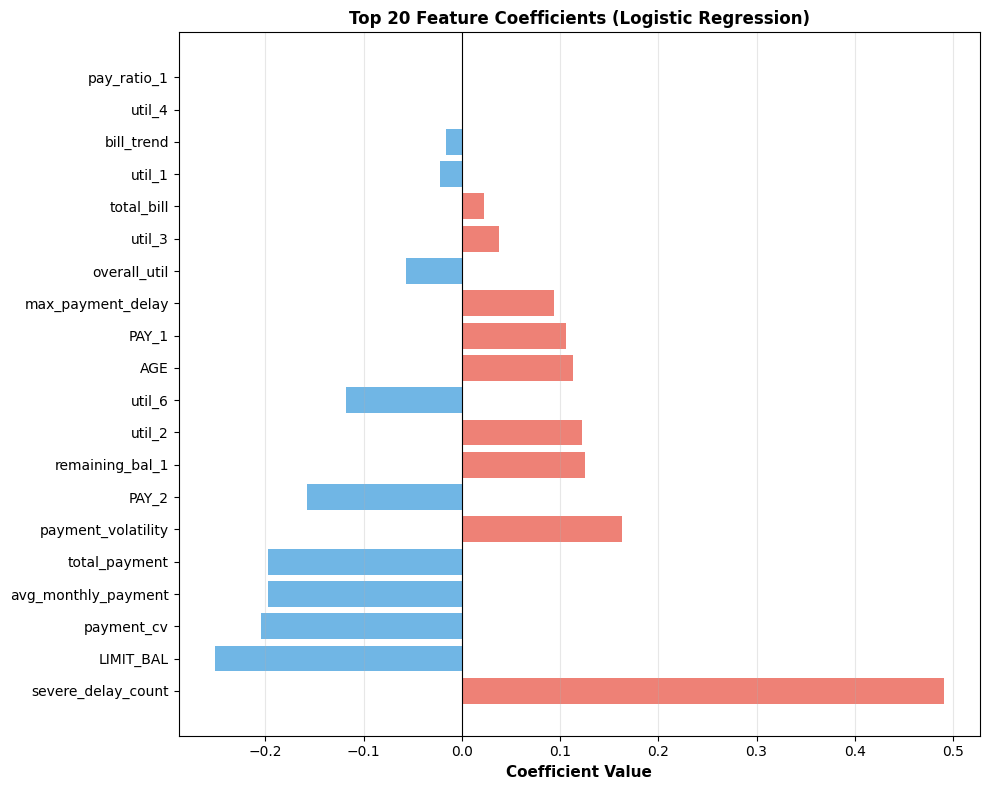


### Saving Model and Artifacts
--------------------------------------------------------------------------------


In [51]:
print("\n### Feature Importance (Logistic Coefficients)")
print("-" * 80)

coefficients = pd.DataFrame({
    'feature': selected_features,
    'coefficient': best_lr_model.coef_[0],
    'abs_coefficient': np.abs(best_lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 15 Most Important Features:")
print(coefficients.head(15).to_string(index=False))

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 8))
top_coefs = coefficients.head(20)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'].values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'].values, fontsize=10)
ax.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Feature Coefficients (Logistic Regression)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'feature_coefficients.png'), dpi=300, bbox_inches='tight')
plt.show()

# ========== SAVE MODEL & ARTIFACTS ==========
print("\n### Saving Model and Artifacts")
print("-" * 80)

# Save model
joblib.dump(best_lr_model, os.path.join(MODELS_DIR, 'logistic_model.pkl'))

# Save selected features list
with open(os.path.join(MODELS_DIR, 'selected_features.pkl'), 'wb') as f:
    pickle.dump(selected_features, f)

# Save results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'model_type': 'LogisticRegression',
    'hyperparameters': lr_best_params,
    'selected_features': selected_features,
    'n_features_selected': len(selected_features),
    'n_features_original': x_train_scaled.shape[1],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'feature_importance': coefficients.to_dict()
}

with open(os.path.join(MODELS_DIR, 'LR_results_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)

FINAL MODEL TRAINING & EVALUATION | XG Boost

Training final model with best hyperparameters...

### Validation Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7828
Accuracy       : 0.8191
Precision      : 0.6836
Recall         : 0.3532
F1-Score       : 0.4657

Confusion Matrix (Validation):
[[3287  162]
 [ 641  350]]

Classification Report (Validation):
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      3449
     Default       0.68      0.35      0.47       991

    accuracy                           0.82      4440
   macro avg       0.76      0.65      0.68      4440
weighted avg       0.80      0.82      0.80      4440


### Test Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7774
Accuracy       : 0.8245
Precision      : 0.6975
Recall         : 0.3770
F1-Score       : 0.4894

Confusion Matrix (Te

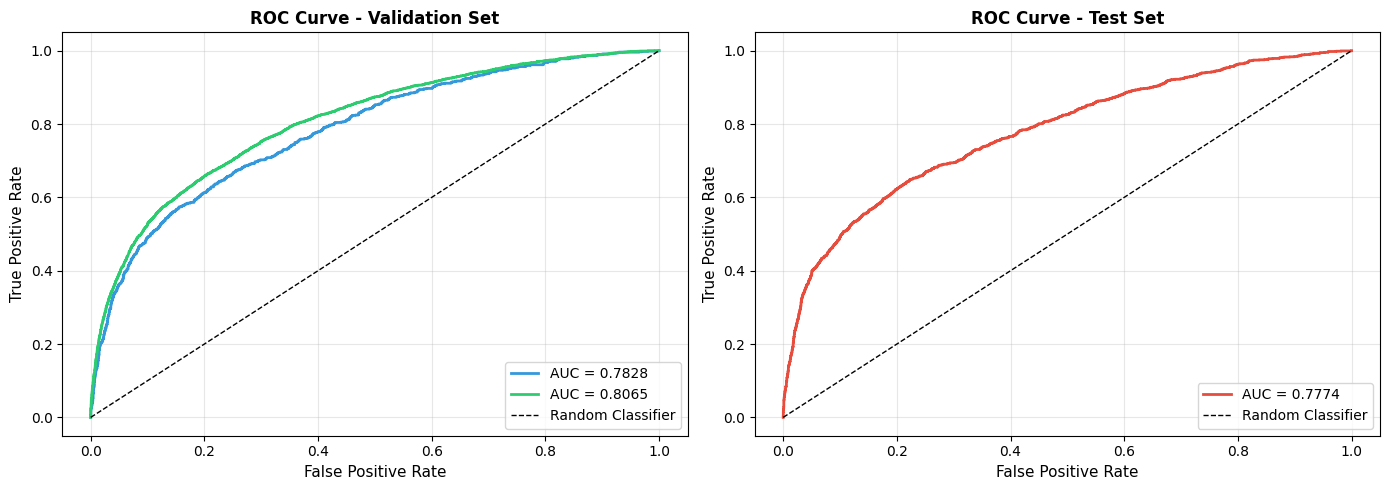

In [52]:
print("FINAL MODEL TRAINING & EVALUATION | XG Boost")
print("="*80)

# Use best model
print("\nTraining final model with best hyperparameters...")
best_xgb_model = xgb.XGBClassifier(
    max_depth=xgb_best_params['max_depth'],
    learning_rate=xgb_best_params['learning_rate'],
    n_estimators=xgb_best_params['n_estimators'],
    subsample=xgb_best_params['subsample'],
    colsample_bytree=xgb_best_params['colsample_bytree'],
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train on full training set
best_xgb_model.fit(x_train_scaled_selected, y_train_scaled)

# ========== VALIDATION SET EVALUATION ==========
print("\n### Validation Set Performance")
print("-" * 80)

y_tr_pred = best_xgb_model.predict(x_train_scaled_selected)
y_tr_pred_proba = best_xgb_model.predict_proba(x_train_scaled_selected)[:, 1]

y_val_pred = best_xgb_model.predict(x_val_scaled_selected)
y_val_pred_proba = best_xgb_model.predict_proba(x_val_scaled_selected)[:, 1]

val_metrics = {
    'AUC-ROC': roc_auc_score(y_val_scaled, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val_scaled, y_val_pred),
    'Precision': precision_score(y_val_scaled, y_val_pred),
    'Recall': recall_score(y_val_scaled, y_val_pred),
    'F1-Score': f1_score(y_val_scaled, y_val_pred)
}

for metric, value in val_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val_scaled, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_scaled, y_val_pred, target_names=['No Default', 'Default']))

# ========== TEST SET EVALUATION ==========
print("\n### Test Set Performance")
print("-" * 80)

y_test_pred = best_xgb_model.predict(x_test_scaled_selected)
y_test_pred_proba = best_xgb_model.predict_proba(x_test_scaled_selected)[:, 1]

test_metrics = {
    'AUC-ROC': roc_auc_score(y_test_scaled, y_test_pred_proba),
    'Accuracy': accuracy_score(y_test_scaled, y_test_pred),
    'Precision': precision_score(y_test_scaled, y_test_pred),
    'Recall': recall_score(y_test_scaled, y_test_pred),
    'F1-Score': f1_score(y_test_scaled, y_test_pred)
}

for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_scaled, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test_scaled, y_test_pred, target_names=['No Default', 'Default']))

# ========== ROC CURVE VISUALIZATION ==========
print("\n### ROC Curve Comparison")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation ROC
fpr_val, tpr_val, _ = roc_curve(y_val_scaled, y_val_pred_proba)
auc_val = roc_auc_score(y_val_scaled, y_val_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC = {auc_val:.4f}', color='#3498db')
fpr_val, tpr_val, _ = roc_curve(y_train_scaled, y_tr_pred_proba)
auc_val = roc_auc_score(y_train_scaled, y_tr_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC = {auc_val:.4f}', color='#2ecc71')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve - Validation Set', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test_scaled, y_test_pred_proba)
auc_test = roc_auc_score(y_test_scaled, y_test_pred_proba)
axes[1].plot(fpr_test, tpr_test, lw=2, label=f'AUC = {auc_test:.4f}', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance (XGB Coefficients)
--------------------------------------------------------------------------------


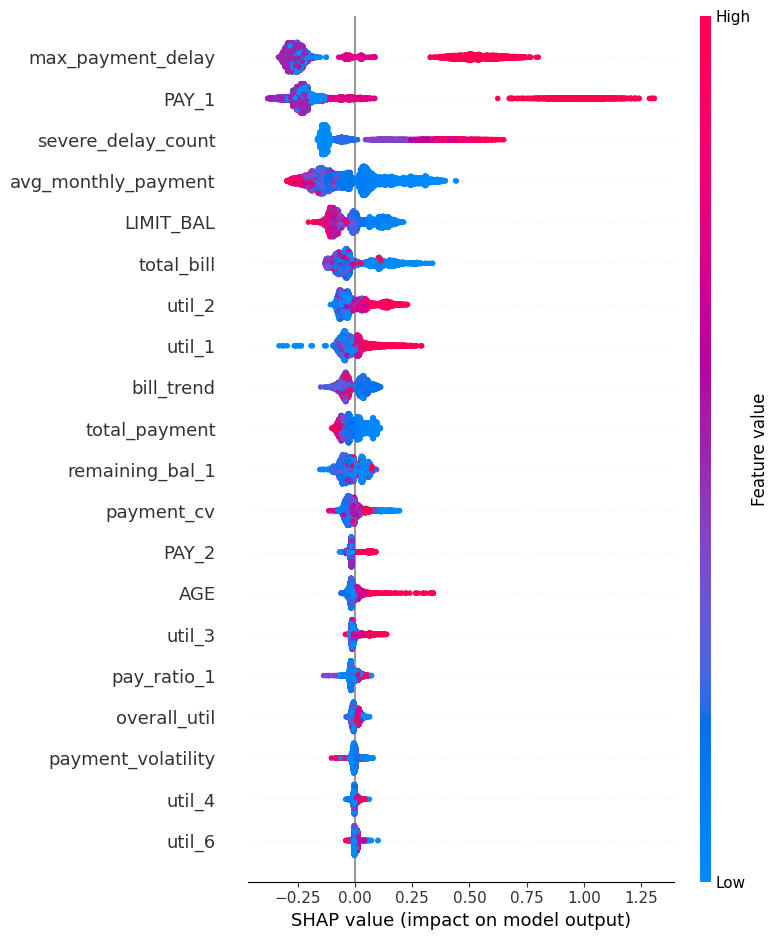

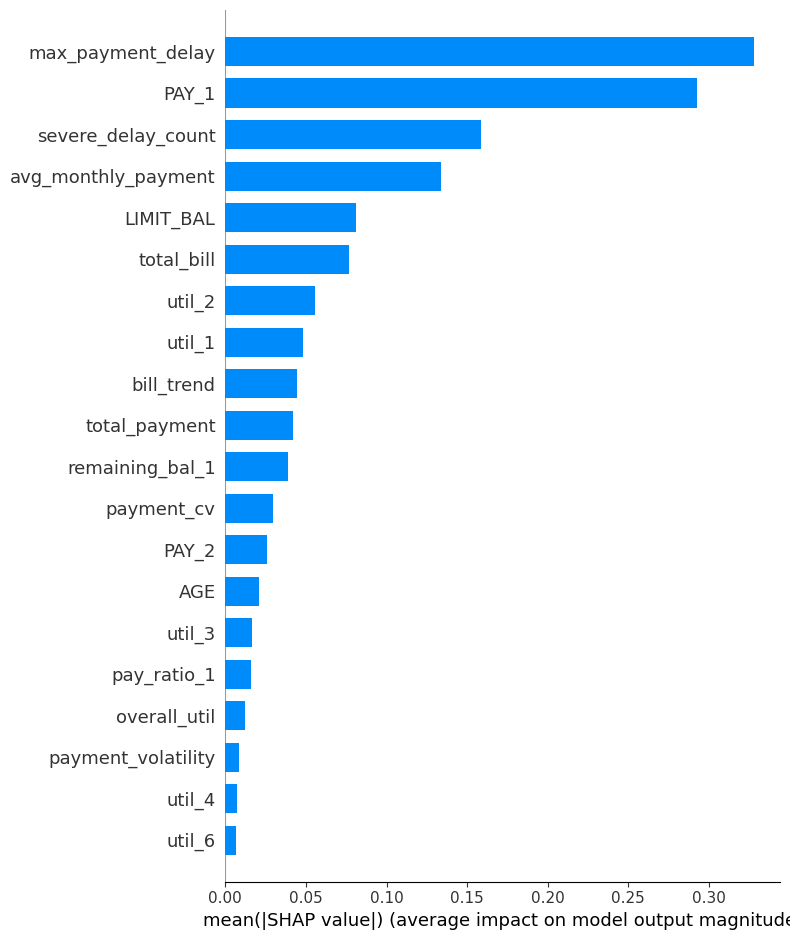


### Saving Model and Artifacts
--------------------------------------------------------------------------------


In [53]:
print("\n### Feature Importance (XGB Coefficients)")
print("-" * 80)

explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(x_test_scaled_selected)

shap.summary_plot(shap_values, x_test_scaled_selected, feature_names=x_test_scaled_selected.columns)
shap.summary_plot(shap_values, x_test_scaled_selected, 
                  feature_names=x_test_scaled_selected.columns, plot_type='bar')

# ========== SAVE MODEL & ARTIFACTS ==========
print("\n### Saving Model and Artifacts")
print("-" * 80)

# Save model
joblib.dump(best_xgb_model, os.path.join(MODELS_DIR, 'xgb_model.pkl'))

shap_df = pd.DataFrame(shap_values, columns=x_test_scaled_selected.columns)

# Calculate mean absolute SHAP value per feature (global importance)
feature_importance = shap_df.abs().mean().sort_values(ascending=False)

# Save results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'model_type': 'XGBoostClassifier',
    'hyperparameters': xgb_best_params,
    'selected_features': selected_features,
    'n_features_selected': len(selected_features),
    'n_features_original': x_train_scaled.shape[1],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'feature_importance': feature_importance.to_dict()
}

with open(os.path.join(MODELS_DIR, 'XGB_results_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)

## Model Comparison Summary

In [54]:
# Function to compute all required metrics
def compute_metrics(y_true, y_pred, y_pred_proba):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    # KS statistic: max difference between CDFs of positive and negative classes
    pos_proba = y_pred_proba[y_true == 1]
    neg_proba = y_pred_proba[y_true == 0]
    ks_stat, _ = ks_2samp(pos_proba, neg_proba)
    return acc, rec, f1, auc, gini, ks_stat

# Compute metrics for Logistic Regression
# Train
y_train_pred_lr = best_lr_model.predict(x_train_scaled_selected)
y_train_pred_proba_lr = best_lr_model.predict_proba(x_train_scaled_selected)[:, 1]
train_acc_lr, train_rec_lr, train_f1_lr, train_auc_lr, train_gini_lr, train_ks_lr = compute_metrics(y_train_scaled, y_train_pred_lr, y_train_pred_proba_lr)

# Validation
y_val_pred_lr = best_lr_model.predict(x_val_scaled_selected)
y_val_pred_proba_lr = best_lr_model.predict_proba(x_val_scaled_selected)[:, 1]
val_acc_lr, val_rec_lr, val_f1_lr, val_auc_lr, val_gini_lr, val_ks_lr = compute_metrics(y_val_scaled, y_val_pred_lr, y_val_pred_proba_lr)

# Test
y_test_pred_lr = best_lr_model.predict(x_test_scaled_selected)
y_test_pred_proba_lr = best_lr_model.predict_proba(x_test_scaled_selected)[:, 1]
test_acc_lr, test_rec_lr, test_f1_lr, test_auc_lr, test_gini_lr, test_ks_lr = compute_metrics(y_test_scaled, y_test_pred_lr, y_test_pred_proba_lr)

# Compute metrics for XGBoost (using existing predictions) - possible fix for future
# Train
train_acc_xgb, train_rec_xgb, train_f1_xgb, train_auc_xgb, train_gini_xgb, train_ks_xgb = compute_metrics(y_train, y_tr_pred, y_tr_pred_proba)

# Validation
val_acc_xgb, val_rec_xgb, val_f1_xgb, val_auc_xgb, val_gini_xgb, val_ks_xgb = compute_metrics(y_val, y_val_pred, y_val_pred_proba)

# Test
test_acc_xgb, test_rec_xgb, test_f1_xgb, test_auc_xgb, test_gini_xgb, test_ks_xgb = compute_metrics(y_test, y_test_pred, y_test_pred_proba)

# Create DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression'] * 3 + ['XGBoost'] * 3,
    'Dataset': ['Train', 'Validation', 'Test'] * 2,
    'Accuracy': [train_acc_lr, val_acc_lr, test_acc_lr, train_acc_xgb, val_acc_xgb, test_acc_xgb],
    'Recall': [train_rec_lr, val_rec_lr, test_rec_lr, train_rec_xgb, val_rec_xgb, test_rec_xgb],
    'F1-Score': [train_f1_lr, val_f1_lr, test_f1_lr, train_f1_xgb, val_f1_xgb, test_f1_xgb],
    'AUC-ROC': [train_auc_lr, val_auc_lr, test_auc_lr, train_auc_xgb, val_auc_xgb, test_auc_xgb],
    'Gini': [train_gini_lr, val_gini_lr, test_gini_lr, train_gini_xgb, val_gini_xgb, test_gini_xgb],
    'KS': [train_ks_lr, val_ks_lr, test_ks_lr, train_ks_xgb, val_ks_xgb, test_ks_xgb]

})
# Set double level index for Model and Dataset
comparison_df.set_index(['Model', 'Dataset'], inplace=True)
# Print the DataFrame
comparison_df

Accuracy    Recall  F1-Score   AUC-ROC  \
Model               Dataset                                              
Logistic Regression Train       0.752651  0.616352  0.526515  0.757966   
                    Validation  0.745946  0.610494  0.517536  0.750454   
                    Test        0.744300  0.614686  0.517527  0.743772   
XGBoost             Train       0.825364  0.370603  0.486396  0.806538   
                    Validation  0.819144  0.353179  0.465735  0.782837   
                    Test        0.824523  0.376987  0.489435  0.777364   

                                    Gini        KS  
Model               Dataset                         
Logistic Regression Train       0.515932  0.408759  
                    Validation  0.500907  0.396323  
                    Test        0.487544  0.397869  
XGBoost             Train       0.613077  0.458276  
                    Validation  0.565674  0.418470  
                    Test        0.554729  0.425603

In [55]:
# Best model by metric in test set
test_comparison = comparison_df.xs('Test', level='Dataset')

for metric in test_comparison.columns:
    best_model = test_comparison[metric].idxmax()
    best_value = test_comparison.loc[best_model, metric]
    print(f"Best {metric}: {best_model} with value {best_value:.4f}")

Best Accuracy: XGBoost with value 0.8245
Best Recall: Logistic Regression with value 0.6147
Best F1-Score: Logistic Regression with value 0.5175
Best AUC-ROC: XGBoost with value 0.7774
Best Gini: XGBoost with value 0.5547
Best KS: XGBoost with value 0.4256
